In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("Path to dataset files:", path)

100%|██████████| 239M/239M [00:11<00:00, 22.7MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/realwaste")

print("Path to dataset files:", path)

100%|██████████| 657M/657M [00:26<00:00, 25.9MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/joebeachcapital/realwaste/versions/1


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import shutil
import random
from tqdm import tqdm
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, Model
from google.colab import drive




### Mounting google colab.

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Exploration

In [4]:
datasets = {
    "garbage_classification": "/kaggle/input/garbage-classification",
    "garbage_12_classes": "/root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1",
    "realwaste": "/root/.cache/kagglehub/datasets/joebeachcapital/realwaste/versions/1",
}

for name, path in datasets.items():
    print(f"\n{'='*40}")
    print(f"Dataset: {name}")
    total = 0
    for root, dirs, files in os.walk(path):
        if files and not dirs:
            class_name = os.path.basename(root)
            count = len(files)
            total += count
            print(f"  {class_name:20s} -> {count:>5}")
    print(f"  {'TOTAL':20s} -> {total:>5}")



Dataset: garbage_classification
  metal                ->   410
  glass                ->   501
  paper                ->   594
  trash                ->   137
  cardboard            ->   403
  plastic              ->   482
  metal                ->   410
  glass                ->   501
  paper                ->   594
  trash                ->   137
  cardboard            ->   403
  plastic              ->   482
  TOTAL                ->  5054

Dataset: garbage_12_classes
  battery              ->   945
  cardboard            ->   891
  trash                ->   697
  brown-glass          ->   607
  metal                ->   769
  white-glass          ->   775
  clothes              ->  5325
  biological           ->   985
  green-glass          ->   629
  paper                ->  1050
  shoes                ->  1977
  plastic              ->   865
  TOTAL                -> 15515

Dataset: realwaste
  Food Organics        ->   411
  Cardboard            ->   461
  Glass               

### Dataset Unification

In [5]:
# Class mapping for each dataset
CLASS_MAP = {
    # garbage_classification
    "cardboard": "cardboard",
    "glass": "glass",
    "metal": "metal",
    "paper": "paper",
    "plastic": "plastic",
    "trash": "trash",
    
    # garbage_12_classes
    "brown-glass": "glass",
    "green-glass": "glass",
    "white-glass": "glass",
    "biological": "organic",
    "clothes": "textile",
    
    # realwaste
    "Cardboard": "cardboard",
    "Glass": "glass",
    "Metal": "metal",
    "Paper": "paper",
    "Plastic": "plastic",
    "Miscellaneous Trash": "trash",
    "Food Organics": "organic",
    "Vegetation": "organic",
    "Textile Trash": "textile",
}

UNIFIED_PATH = "/content/unified_dataset"
os.makedirs(UNIFIED_PATH, exist_ok=True)

datasets = {
    "garbage_classification": "/kaggle/input/garbage-classification",
    "garbage_12_classes": "/root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1",
    "realwaste": "/root/.cache/kagglehub/datasets/joebeachcapital/realwaste/versions/1",
}

counter = {}

for dataset_name, dataset_path in datasets.items():
    for root, dirs, files in os.walk(dataset_path):
        if files and not dirs:
            original_class = os.path.basename(root)
            
            if original_class not in CLASS_MAP:
                continue  # Skipping battery and shoes.
            
            unified_class = CLASS_MAP[original_class]
            dest_dir = os.path.join(UNIFIED_PATH, unified_class)
            os.makedirs(dest_dir, exist_ok=True)
            
            for f in files:
                src = os.path.join(root, f)
                # Prefix to avoid name collisions
                new_name = f"{dataset_name}_{original_class}_{f}"
                dst = os.path.join(dest_dir, new_name)
                shutil.copy2(src, dst)
                counter[unified_class] = counter.get(unified_class, 0) + 1

print("Unified dataset:")
for cls, count in sorted(counter.items()):
    print(f"  {cls:15s} -> {count:>5}")
print(f"  {'TOTAL':15s} -> {sum(counter.values()):>5}")


Unified dataset:
  cardboard       ->  2158
  glass           ->  3433
  metal           ->  2379
  organic         ->  1832
  paper           ->  2738
  plastic         ->  2750
  textile         ->  5643
  trash           ->  1466
  TOTAL           -> 22399


### Train / Val / Test Split

In [6]:
UNIFIED_PATH = "/content/unified_dataset"
SPLIT_PATH = "/content/dataset_split"
MAX_PER_CLASS = 2500  # Cap to balance classes
SEED = 42

random.seed(SEED)

train_count = {}
val_count = {}
test_count = {}

for cls in sorted(os.listdir(UNIFIED_PATH)):
    cls_path = os.path.join(UNIFIED_PATH, cls)
    files = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    random.shuffle(files)
    
    # Cap if too many
    files = files[:MAX_PER_CLASS]
    
    # Split 80/10/10
    n = len(files)
    n_train = int(n * 0.8)
    n_val = int(n * 0.1)
    
    splits = {
        "train": files[:n_train],
        "val": files[n_train:n_train + n_val],
        "test": files[n_train + n_val:],
    }
    
    for split_name, split_files in splits.items():
        dest = os.path.join(SPLIT_PATH, split_name, cls)
        os.makedirs(dest, exist_ok=True)
        for f in split_files:
            shutil.copy2(os.path.join(cls_path, f), os.path.join(dest, f))
    
    train_count[cls] = len(splits["train"])
    val_count[cls] = len(splits["val"])
    test_count[cls] = len(splits["test"])

print(f"{'Class':15s} {'Train':>6} {'Val':>6} {'Test':>6}")
print("-" * 35)
for cls in sorted(train_count):
    print(f"{cls:15s} {train_count[cls]:>6} {val_count[cls]:>6} {test_count[cls]:>6}")
print("-" * 35)
print(f"{'TOTAL':15s} {sum(train_count.values()):>6} {sum(val_count.values()):>6} {sum(test_count.values()):>6}")


Class            Train    Val   Test
-----------------------------------
cardboard         1404    175    176
glass             2000    250    250
metal             1575    196    198
organic           1465    183    184
paper             1715    214    215
plastic           1814    226    228
textile           2000    250    250
trash             1063    132    134
-----------------------------------
TOTAL            13036   1626   1635


### EDA - Exploratory Data Analysis

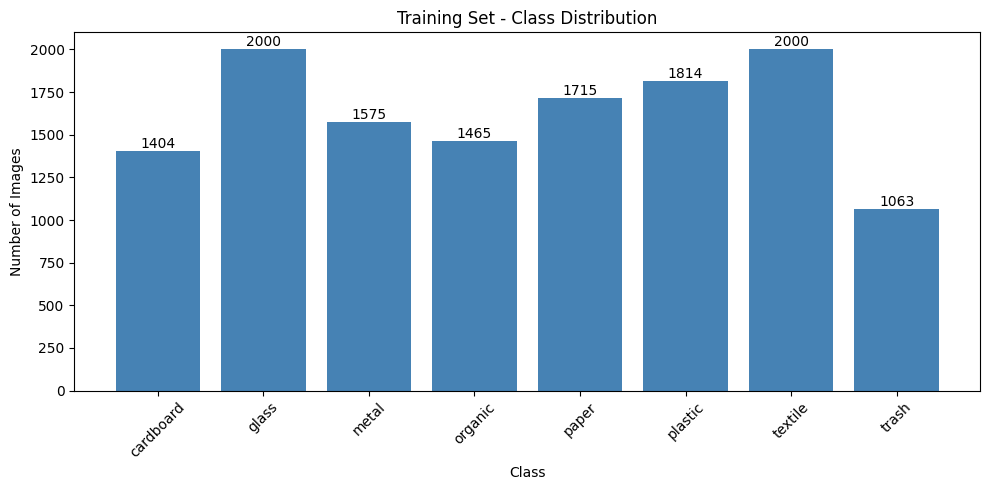

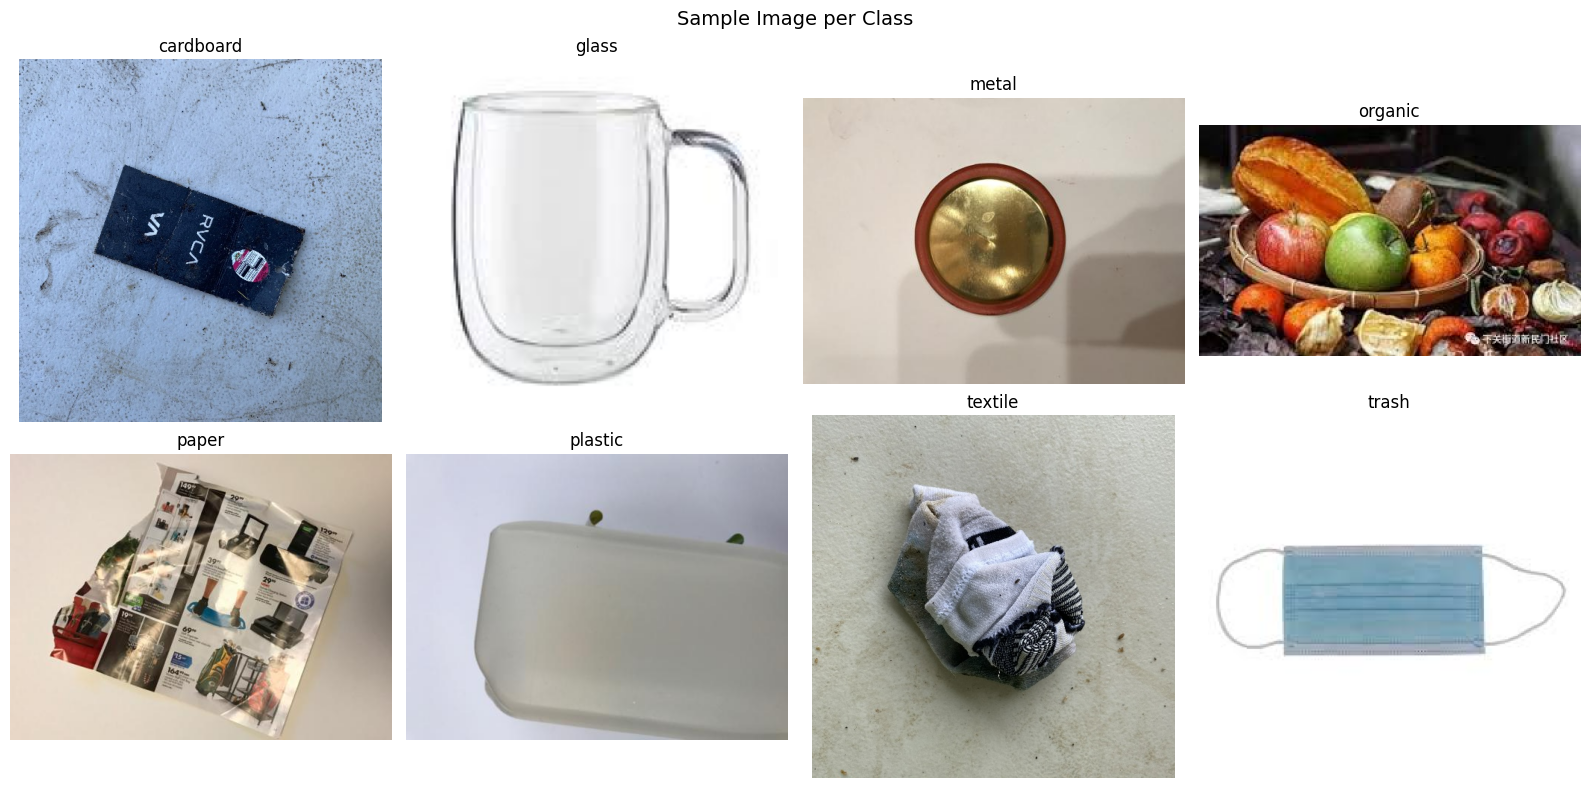

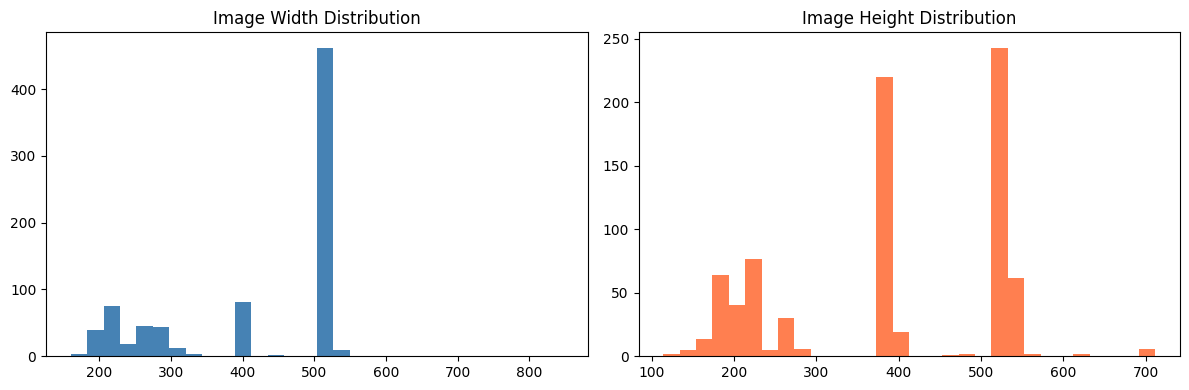

Width  - min: 160, max: 847, mean: 424
Height - min: 114, max: 712, mean: 390


In [7]:
SPLIT_PATH = "/content/dataset_split"

# Class distribution
classes = sorted(os.listdir(os.path.join(SPLIT_PATH, "train")))
train_counts = [len(os.listdir(os.path.join(SPLIT_PATH, "train", c))) for c in classes]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, train_counts, color='steelblue')
plt.bar_label(bars)
plt.title("Training Set - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sample images per class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flat, classes):
    cls_path = os.path.join(SPLIT_PATH, "train", cls)
    img_name = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_name))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample Image per Class", fontsize=14)
plt.tight_layout()
plt.show()

# Image size distribution
widths, heights = [], []
for cls in classes:
    cls_path = os.path.join(SPLIT_PATH, "train", cls)
    for f in os.listdir(cls_path)[:100]:  # Sample 100 per class
        img = Image.open(os.path.join(cls_path, f))
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths, bins=30, color='steelblue')
ax1.set_title("Image Width Distribution")
ax2.hist(heights, bins=30, color='coral')
ax2.set_title("Image Height Distribution")
plt.tight_layout()
plt.show()

print(f"Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")


### Save Preprocessed Data as NumPy Arrays

In [8]:
IMG_SIZE = 224 #Resize
SPLIT_PATH = "/content/dataset_split"
classes = sorted(os.listdir(os.path.join(SPLIT_PATH, "train")))

print("Classes:", classes)
print("Class index mapping:")
for i, c in enumerate(classes):
    print(f"  {i}: {c}")

def load_split(split_name):
    images, labels = [], []
    split_dir = os.path.join(SPLIT_PATH, split_name)
    for idx, cls in enumerate(classes):
        cls_path = os.path.join(split_dir, cls)
        files = os.listdir(cls_path)
        for f in tqdm(files, desc=f"{split_name}/{cls}"):
            img = Image.open(os.path.join(cls_path, f)).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img))
            labels.append(idx)
    return np.array(images), np.array(labels)

X_train, y_train = load_split("train")
X_val, y_val = load_split("val")
X_test, y_test = load_split("test")

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

# Save to Google Drive
np.savez_compressed("/content/drive/MyDrive/waste_dataset_224.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test)

print("\nDataset saved to Google Drive")


Classes: ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'textile', 'trash']
Class index mapping:
  0: cardboard
  1: glass
  2: metal
  3: organic
  4: paper
  5: plastic
  6: textile
  7: trash


test/trash: 100%|██████████| 134/134 [00:00<00:00, 180.11it/s]



X_train: (13036, 224, 224, 3), y_train: (13036,)
X_val:   (1626, 224, 224, 3),   y_val:   (1626,)
X_test:  (1635, 224, 224, 3),  y_test:  (1635,)

Dataset saved to Google Drive


### Loading Data from Drive
* Mount Drive — connects Colab to your Google Drive 
* Load .npz — reads the preprocessed images and labels you saved earlier 
* Split into variables — X = images, y = labels, for train/val/test
* CLASS_NAMES — maps index 0-7 to class names
* Normalize — converts pixel values from 0-255 to 0-1 (neural networks train better with small numbers)
* Print shapes — confirms data loaded correctly

In [12]:
SPLIT_PATH = "/content/dataset_split"
IMG_SIZE = 224
BATCH_SIZE = 32

CLASS_NAMES = ["cardboard", "glass", "metal", "organic", "paper", "plastic", "trash"]

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_PATH}/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=CLASS_NAMES
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_PATH}/val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=CLASS_NAMES
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{SPLIT_PATH}/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=CLASS_NAMES
)

# Normalize and optimize pipeline
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)

print("Data loaded successfully")
print(f"Classes: {CLASS_NAMES}")


Found 11036 files belonging to 7 classes.
Found 1376 files belonging to 7 classes.
Found 1385 files belonging to 7 classes.
Data loaded successfully
Classes: ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']


In [ ]:
import os
import csv

SPLIT_PATH = "/content/dataset_split"
rows = []

for split in ["train", "val", "test"]:
    split_dir = os.path.join(SPLIT_PATH, split)
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        for f in os.listdir(cls_path):
            rows.append([f, cls, split])

import pandas as pd
df = pd.DataFrame(rows, columns=["filename", "class", "split"])

print(df.head(10))
print(f"\nTotal: {len(df)}")
print(df["class"].value_counts())

df.to_csv("/content/drive/MyDrive/waste_metadata.csv", index=False)
print("\nSaved to Google Drive")

                                            filename      class  split
0               realwaste_Cardboard_Cardboard_94.jpg  cardboard  train
1              realwaste_Cardboard_Cardboard_367.jpg  cardboard  train
2              realwaste_Cardboard_Cardboard_361.jpg  cardboard  train
3      garbage_12_classes_cardboard_cardboard448.jpg  cardboard  train
4              realwaste_Cardboard_Cardboard_428.jpg  cardboard  train
5      garbage_12_classes_cardboard_cardboard302.jpg  cardboard  train
6  garbage_classification_cardboard_cardboard244.jpg  cardboard  train
7  garbage_classification_cardboard_cardboard154.jpg  cardboard  train
8  garbage_classification_cardboard_cardboard176.jpg  cardboard  train
9      garbage_12_classes_cardboard_cardboard591.jpg  cardboard  train

Total: 16297
class
glass        2500
textile      2500
plastic      2268
paper        2144
metal        1969
organic      1832
cardboard    1755
trash        1329
Name: count, dtype: int64

Saved to Google Drive


## Model - EfficientNetV2-S (Transfer Learning)
* EfficientNetV2S — loads a pre-trained model (trained on ImageNet with millions of images). include_top=False removes its original classification head
* Frozen backbone (trainable=False) — we don't modify the pre-trained weights, only train our custom layers on top
-  Custom head:
* GlobalAveragePooling2D — compresses feature maps into a single vector
* Dropout(0.3) — randomly drops 30% of neurons to prevent overfitting
* Dense(256, relu) — hidden layer with 256 neurons
* Dense(8, softmax) — output layer, 8 probabilities (one per class)
- Compile:
* Adam(1e-3) — optimizer with learning rate 0.001
* sparse_categorical_crossentropy — loss function for multiclass with integer labels
* accuracy — metric to track

In [14]:
# Phase 1: Frozen backbone
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,661,095 (78.82 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

### Training - Phase 1 (Frozen Backbone)

In [ ]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
    ]
)


Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2645s 8s/step - accuracy: 0.3204 - loss: 1.7411 - val_accuracy: 0.4019 - val_loss: 1.6317 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2611s 8s/step - accuracy: 0.3610 - loss: 1.6626 - val_accuracy: 0.4041 - val_loss: 1.5855 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2627s 8s/step - accuracy: 0.3758 - loss: 1.6343 - val_accuracy: 0.4353 - val_loss: 1.5442 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2718s 8s/step - accuracy: 0.3851 - loss: 1.6126 - val_accuracy: 0.4193 - val_loss: 1.5302 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2588s 8s/step - accuracy: 0.3888 - loss: 1.5986 - val_accuracy: 0.4448 - val_loss: 1.5119 - learning_rate: 0.0010
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2679s 8s/step - accuracy: 0.3993 - loss: 1.5911 - val_accuracy: 0.4477 - val_loss: 1.4978 - learning_rate: 0.0010
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2707s 8s/step - accuracy: 0.3949 - l